# Notebook 6 — Beware the filter

*SWC ENC 2026 · ephys-one module · independent of Notebooks 4, 5, 7*

Every patch-clamp amplifier has a **low-pass filter** on its output — usually a
Bessel filter with a cutoff you dial in (2 kHz, 5 kHz, 10 kHz…). It is there for good
reason: it removes high-frequency instrument noise and prevents aliasing. But noise
analysis *lives* on fluctuations, and a filter is a device for removing fluctuations.
Set it too slow and it quietly eats the very signal you're measuring. This notebook
shows how, and how to tell.

**In this notebook you will:**
1. See what a low-pass filter does to a single channel's record.
2. Filter a macroscopic recording at several cutoffs and watch the parabola shrink.
3. Find the rule of thumb for a safe cutoff.
4. Meet **flickering** channels, where the filter makes the analysis lie
   convincingly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import bessel, sosfilt
import picopatch as pp

scheme = pp.two_state()

## 1. What a low-pass filter does

A **low-pass filter** lets slow changes through and smooths out fast ones. Its one
important number is the **cutoff frequency** $f_c$: wiggles much slower than $f_c$
pass unchanged, wiggles much faster are flattened. Equivalently, the filter has a
**time constant** $\tau_f \approx 1/(2\pi f_c)$ — roughly the shortest event it can
still represent faithfully. A 1 kHz filter has $\tau_f \approx 0.16$ ms; a 150 Hz
filter, about 1 ms.

Here is a single channel's record (the switch of Notebook 1, at 45 mV where it dwells
~7 ms in each state) seen through progressively slower filters:

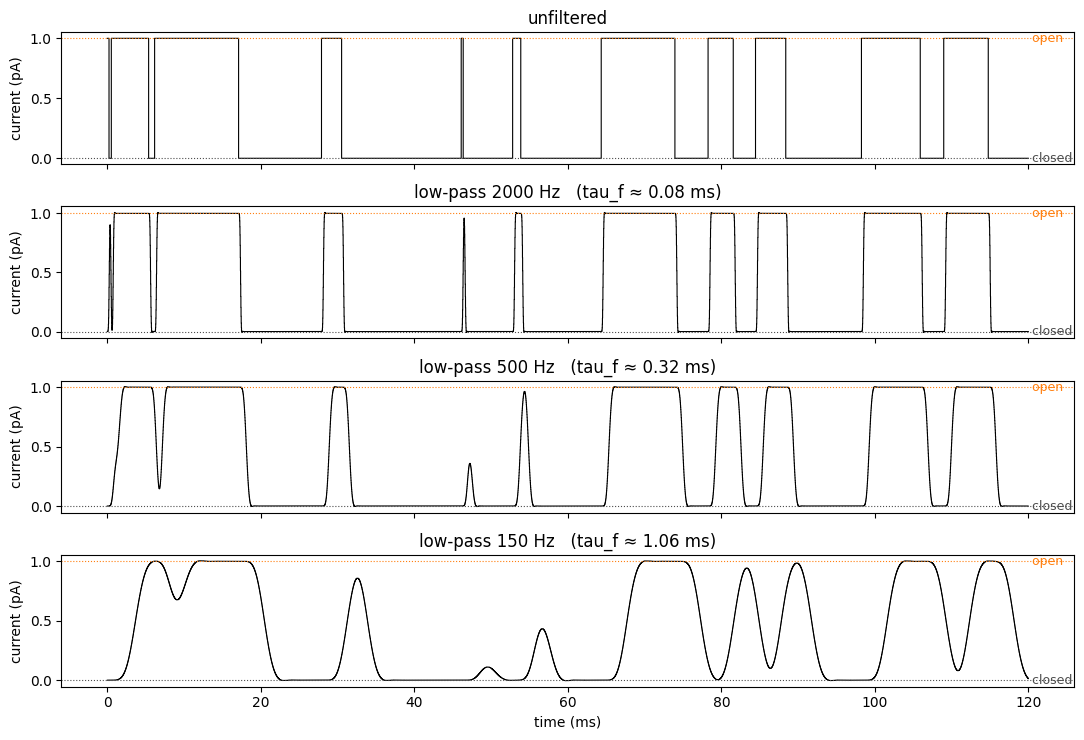

In [2]:
def lowpass(x, fs, fc, order=8):
    # 8-pole Bessel low-pass, applied causally along the last axis, like an amplifier's filter
    sos = bessel(order, fc, btype="low", fs=fs, output="sos", norm="mag")
    return sosfilt(sos, x, axis=-1)

prot45 = pp.constant_protocol(45, duration_ms=120)
raw = pp.current_from_states(scheme, pp.simulate_single(scheme, prot45, 1, rng=0)[0], 1.0)

fig, axes = plt.subplots(4, 1, figsize=(11, 7.5), sharex=True)
pp.plotting.plot_single_channel(prot45.t_ms, raw, ax=axes[0], i=1.0, title="unfiltered")
for ax, fc in zip(axes[1:], [2000, 500, 150]):
    pp.plotting.plot_single_channel(prot45.t_ms, lowpass(raw, pp.FS, fc), ax=ax, i=1.0,
                                    title=f"low-pass {fc} Hz   (tau_f ≈ {1e3/(2*np.pi*fc):.2f} ms)")
for ax in axes[:-1]:
    ax.set_xlabel("")
plt.tight_layout(); plt.show()

At 2 kHz the record is essentially intact. At 500 Hz the corners are rounded and the
briefest events have lost height. At 150 Hz the short openings no longer reach the
open level at all — the channel *appears* to pass less current than it does — and
short closures are filled in. The amplitude the filter reports depends on how long
the event lasted. Since noise analysis estimates the unitary current from the
*fluctuations*, and the filter has just shrunk them, you can guess what's coming.

<details>
<summary><b>▸ Go deeper: filters remove variance (optional)</b></summary>

Think of the fluctuating current as a mixture of frequencies, each carrying some of
the variance (the **power spectrum**; Notebook 7 builds this up). A filter multiplies
the power at frequency $f$ by $|H(f)|^2$, which is ≈ 1 below $f_c$ and falls towards
0 above it. The variance after filtering is $\int S(f)\,|H(f)|^2\,df$ — the part of
the variance that lives below the cutoff. For a two-state channel the spectrum is a
Lorentzian with corner frequency $1/(2\pi\tau)$, $\tau = 1/(\alpha+\beta)$ the gating
time constant; a filter with $f_c$ well above that corner removes almost nothing,
one with $f_c$ near or below it removes a large fraction. Because the mean current is
untouched (it's at zero frequency), the parabola is squashed vertically: lower
apparent $i$, higher apparent $N$.
</details>

## 2. Filtering the macroscopic current

Now apply the same filters to an ensemble of sweeps. We use a small patch (10
channels) and many sweeps (2000) so the fluctuations are large and the parabola
clean, and we filter each sweep as the amplifier would — before any analysis.

**Exercise 1** *(~4 min)*. The `lowpass` function above is already written; use it
to filter the whole sweep matrix (it works along the last axis, i.e. time) at 2000,
500 and 150 Hz, and fit the parabola to each. Plot all four against the true curve.

> **Check / unstuck.** $i$ should fall from ~1.0 to ~0.96, ~0.77 and ~0.4 pA as the
> cutoff drops, and $N$ should climb. Stuck? `pp.lowpass_bessel(sweeps, fs, fc)`.

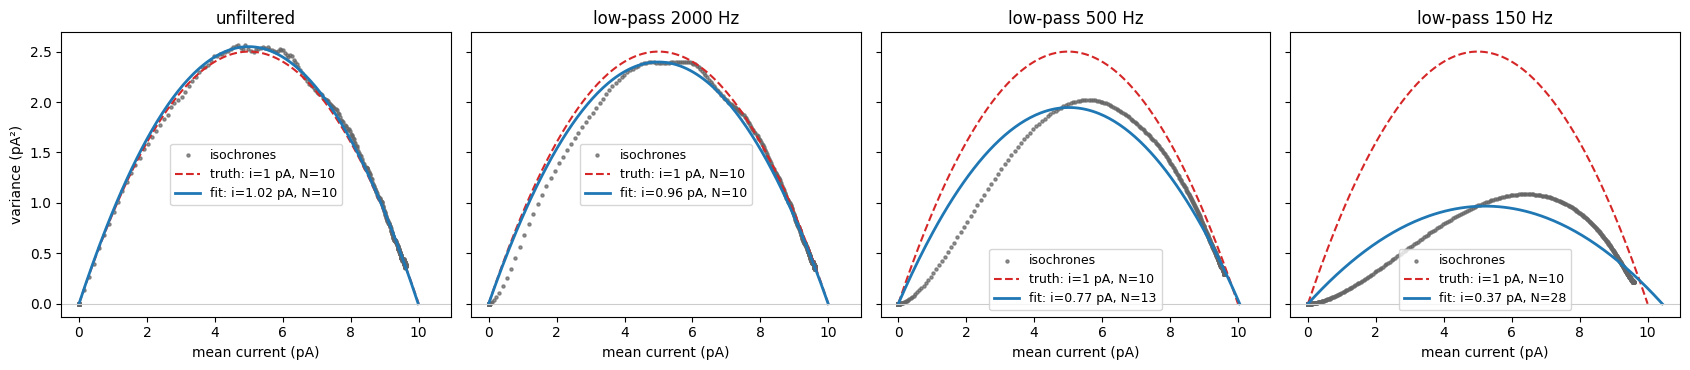

    none:  NoiseFit(i=1.021 pA, N=10, p_max=0.96, baseline=0 pA^2)
 2000 Hz:  NoiseFit(i=0.959 pA, N=10, p_max=0.96, baseline=0 pA^2)
  500 Hz:  NoiseFit(i=0.774 pA, N=13, p_max=0.96, baseline=0 pA^2)
  150 Hz:  NoiseFit(i=0.371 pA, N=28, p_max=0.92, baseline=0 pA^2)


In [3]:
exp = pp.make_experiment(N=10, i=1.0, scheme=scheme, n_sweeps=2000, seed=5)
cutoffs = [None, 2000, 500, 150]

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8), sharex=True, sharey=True)
fits = {}
for ax, fc in zip(axes, cutoffs):
    sweeps = exp.sweeps if fc is None else lowpass(exp.sweeps, exp.fs, fc)
    m, v = pp.isochrone_stats(sweeps)
    fits[fc] = pp.fit_parabola(m, v)
    pp.plotting.plot_variance_mean(m, v, fit=fits[fc], truth=exp.truth, ax=ax, s=5, color="0.4",
                                   title="unfiltered" if fc is None else f"low-pass {fc} Hz")
    ax.set_ylabel("variance (pA²)" if fc is None else "")
plt.tight_layout(); plt.show()
for fc, f in fits.items():
    print(f"{'none' if fc is None else str(fc) + ' Hz':>8}:  {f}")

The paper's Fig. 11, reproduced: the parabola keeps its width (the mean is untouched,
so it still closes at $iN$) but loses height, and the fit reads that as a smaller $i$
and a larger $N$. Notice too the **foot** that appears at low mean current in the
heavily filtered panel — the curve no longer leaves the origin with slope $i$, so even
the slope-only estimate of Notebook 5 fails.

## 3. How fast is fast enough?

The damage depends on the filter's speed *relative to the channel's*. The relevant
channel timescale is the gating time constant $\tau = 1/(\alpha+\beta)$ at the test
voltage — here 1.3 ms at +65 mV.

**Exercise 2** *(~6 min)*. Sweep the cutoff from 100 Hz to 10 kHz (say 12 values,
log-spaced), fit at each, and plot the estimated $i$ (as a fraction of the truth)
against the ratio $\tau_f / \tau$ where $\tau_f = 1/(2\pi f_c)$. Where does the bias
exceed 5%?

> **Check / unstuck.** The curve should be flat near 1.0 for $\tau_f/\tau$ below
> about 0.1 and fall steeply beyond. That's the paper's rule: keep the filter time
> constant **under a tenth** of the channel's.

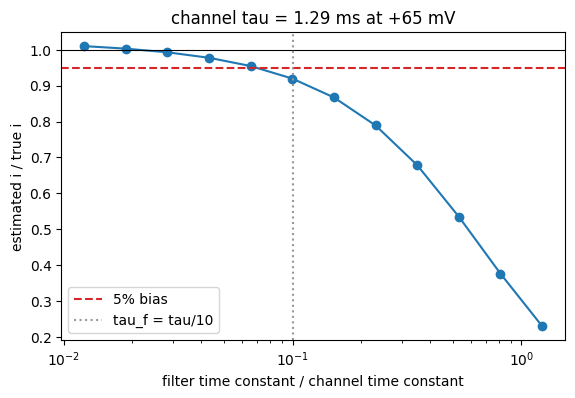

In [4]:
tau_ch = 1.0 / (float(pp.alpha_rate(65)) + float(pp.beta_rate(65)))      # s
fcs = np.logspace(2, 4, 12)
i_est = []
for fc in fcs:
    m, v = pp.isochrone_stats(lowpass(exp.sweeps, exp.fs, fc))
    i_est.append(pp.fit_parabola(m, v).i)
i_est = np.array(i_est)
ratio = (1 / (2 * np.pi * fcs)) / tau_ch

plt.figure(figsize=(6.5, 4))
plt.semilogx(ratio, i_est / exp.truth.i, "o-", color="tab:blue")
plt.axhline(1.0, color="k", lw=0.8); plt.axhline(0.95, color="tab:red", ls="--", label="5% bias")
plt.axvline(0.1, color="0.6", ls=":", label="tau_f = tau/10")
plt.xlabel("filter time constant / channel time constant"); plt.ylabel("estimated i / true i")
plt.title(f"channel tau = {tau_ch*1e3:.2f} ms at +65 mV"); plt.legend(); plt.show()

In practice you don't know the channel's kinetics in advance — that's often what
you're trying to learn. The paper's advice is pragmatic: **repeat the analysis at two
or three filter settings**. If the estimates don't move, the filter is fast enough.
If they do, the fastest setting is the least wrong.

## 4. Flickering channels: when the filter lies convincingly

Some channels don't open cleanly; they **flicker** — burst open and shut hundreds of
times per millisecond. Here's a scheme for that: after a ~1 ms latency the channel
enters a burst in which it flips between C₂ and O at 100 000 /s each way, so within
the burst it is open exactly half the time:

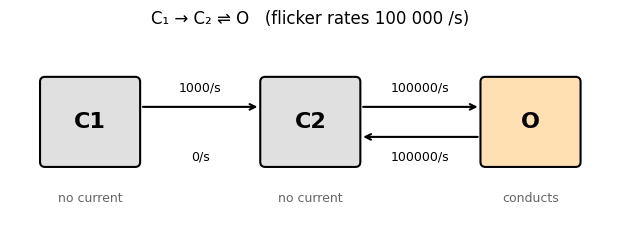

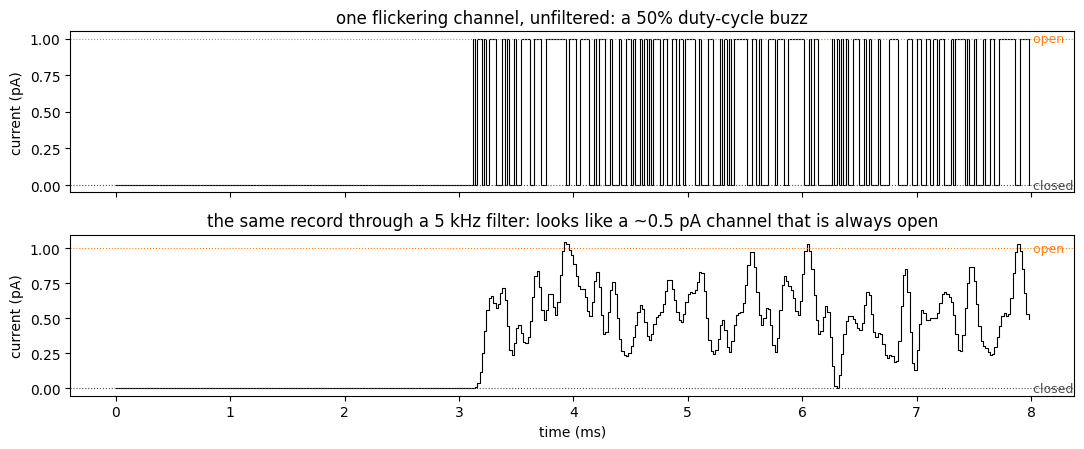

In [5]:
flick = pp.flickering()
fig, ax = plt.subplots(figsize=(9, 2.6))
pp.plotting.plot_scheme(ax, flick, V=65, title="C₁ → C₂ ⇌ O   (flicker rates 100 000 /s)")
plt.show()

prot = pp.step_protocol(v_step=65, t_step_ms=6)
st = pp.simulate_single(flick, prot, 1, rng=3)[0]
raw_f = pp.current_from_states(flick, st, 1.0)

fig, axes = plt.subplots(2, 1, figsize=(11, 4.6), sharex=True)
pp.plotting.plot_single_channel(prot.t_ms, raw_f, ax=axes[0], i=1.0, title="one flickering channel, unfiltered: a 50% duty-cycle buzz")
pp.plotting.plot_single_channel(prot.t_ms, lowpass(raw_f, pp.FS, 5000), ax=axes[1], i=1.0,
                                title="the same record through a 5 kHz filter: looks like a ~0.5 pA channel that is always open")
axes[0].set_xlabel(""); plt.tight_layout(); plt.show()

Unfiltered, the record is a buzz between 0 and 1 pA. Through a perfectly ordinary
5 kHz filter it becomes a smooth level at about 0.5 pA — indistinguishable from a
half-size channel with an open probability near 1. Noise analysis on the filtered
ensemble will report exactly that: a smaller $i$ and a higher $p_{max}$, with $N$
about right. Nothing in the fit will look wrong.

unfiltered:  NoiseFit(i=1.033 pA, N=945, p_max=0.51, baseline=0 pA^2)    (truth i = 1 pA, N = 1000, p_max = 0.50)
   5000 Hz:  NoiseFit(i=0.626 pA, N=961, p_max=0.83, baseline=0 pA^2)    (truth i = 1 pA, N = 1000, p_max = 0.50)


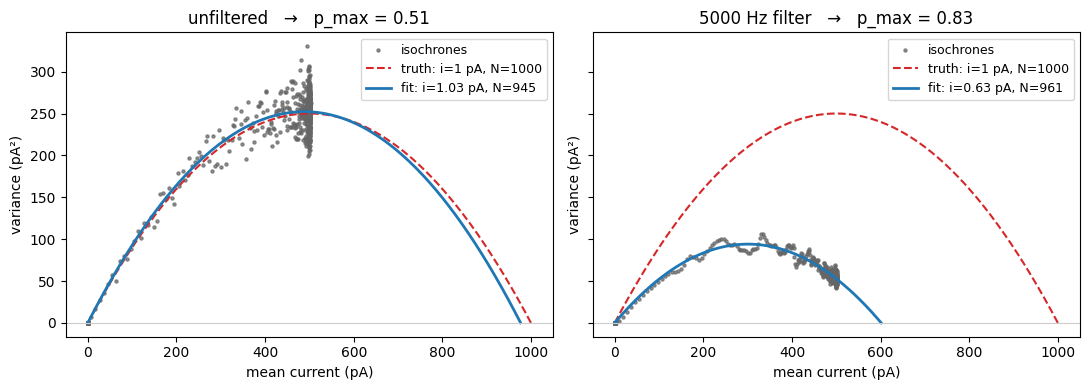

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, fc in zip(axes, [None, 5000]):
    e = pp.make_experiment(N=1000, i=1.0, scheme=flick, n_sweeps=300, filter_fc=fc, seed=4)
    m, v = pp.isochrone_stats(e.sweeps)
    f = pp.fit_parabola(m, v)
    pp.plotting.plot_variance_mean(m, v, fit=f, truth=e.truth, ax=ax, s=5, color="0.4",
                                   title=("unfiltered" if fc is None else f"{fc} Hz filter") + f"   →   p_max = {f.p_max:.2f}")
    print(f"{'unfiltered' if fc is None else str(fc) + ' Hz':>10}:  {f}    (truth i = 1 pA, N = 1000, p_max = {e.truth.p_max:.2f})")
plt.tight_layout(); plt.show()

The paper found $i$ = 0.54 pA and $p_{max}$ = 0.89 for a true 1 pA and 0.5. The
lesson is humbling: noise analysis measures the channel **as seen through the
recording system**. If the system can't follow the flicker, the "unitary current" it
reports is the time-averaged current of a burst, and the "open probability" is the
probability of being in a burst. Both are real, meaningful numbers — just not the
ones you thought you were measuring.

**Where we are.** Low-pass filtering removes variance but not mean, so it squashes the
parabola: $i$ down, $N$ up, and a foot at the origin. Keep the filter time constant
under a tenth of the gating time constant, check that your estimates don't depend on
the filter setting, and remember that fast flicker turns the method's answers into
burst-averaged quantities.